# Daily Challenge: Building Your First Neural Network on the MNIST Dataset


## 1. Load and Preprocess the MNIST Dataset

- Load the MNIST dataset using TensorFlow/Keras
- Normalize the image pixel values to be between 0 and 1
- Convert labels into one-hot encoded format
- Split the dataset into training and test sets
- Display sample images with their corresponding labels

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.datasets import mnist # pyright: ignore[reportMissingImports]

# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train_normal = X_train / 255.0
X_test_normal = X_test / 255.0
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'After normalization, min pixel value: {X_train_normal.min()}, max pixel value: {X_train_normal.max()}')

print(f'Output shape: {y_train.shape}')

Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
After normalization, min pixel value: 0.0, max pixel value: 1.0
Output shape: (60000,)


In [24]:
# one hot encoding for output
from tensorflow.keras.utils import to_categorical # type: ignore
print(f'Before one-hot encoding, y_train labels look like: {y_train[:5]}')

y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print(f'After ont-hot encoding, Output shape: {y_train_encoded.shape}')
print(f'Output labels look like :\n {y_train_encoded[:5]}')




Before one-hot encoding, y_train labels look like: [5 0 4 1 9]
After ont-hot encoding, Output shape: (60000, 10)
Output labels look like :
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


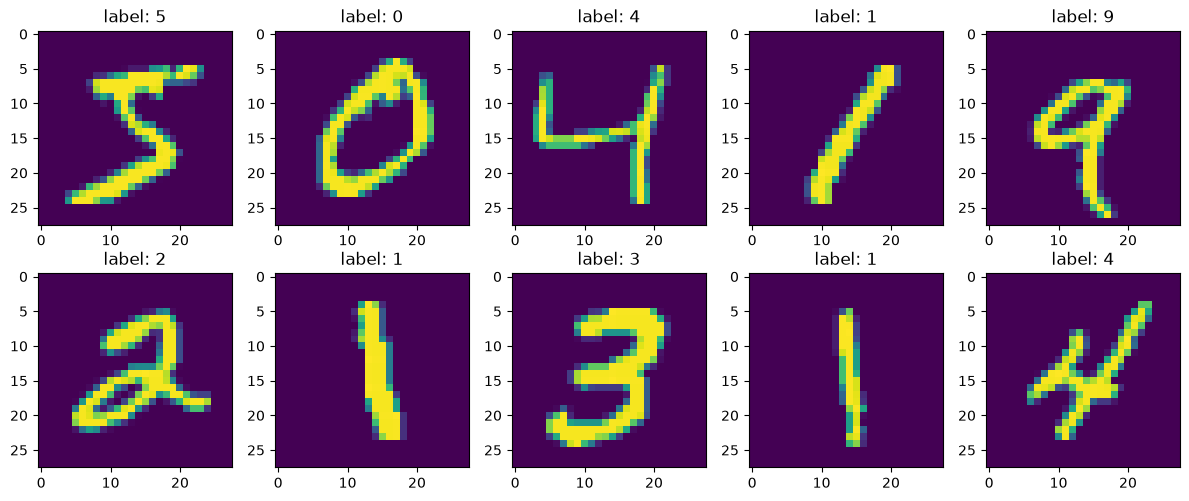

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f'True label: {y_train[i]}')
    
plt.tight_layout()
plt.show()

## 2. Build a Fully Connected Neural Network

- Define a sequential model using Keras
- Flatten the 28x28 input images into a single vector
- Add two hidden layers with ReLU activation
- Add an output layer with Softmax activation for multi-class classification
- Compile the model using categorical cross-entropy as the loss function and accuracy as the evaluation metric


In [41]:
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## 3. Train the Neural Network

- Fit the model to the training data for 10 epochs
- Use a validation set to track performance during training
- Observe the loss and accuracy trends over the epochs

In [43]:
history = model.fit(
    X_train_normal, 
    y_train_encoded, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9262 - loss: 0.2493 - val_accuracy: 0.9708 - val_loss: 0.1051
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9684 - loss: 0.1039 - val_accuracy: 0.9745 - val_loss: 0.0842
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9771 - loss: 0.0720 - val_accuracy: 0.9720 - val_loss: 0.0953
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9824 - loss: 0.0551 - val_accuracy: 0.9758 - val_loss: 0.0849
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9861 - loss: 0.0431 - val_accuracy: 0.9758 - val_loss: 0.0885
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9880 - loss: 0.0356 - val_accuracy: 0.9735 - val_loss: 0.0960
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9907 - loss: 0.0285 - val_accuracy: 0.9768 - val_loss: 0.0976
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0252 - 

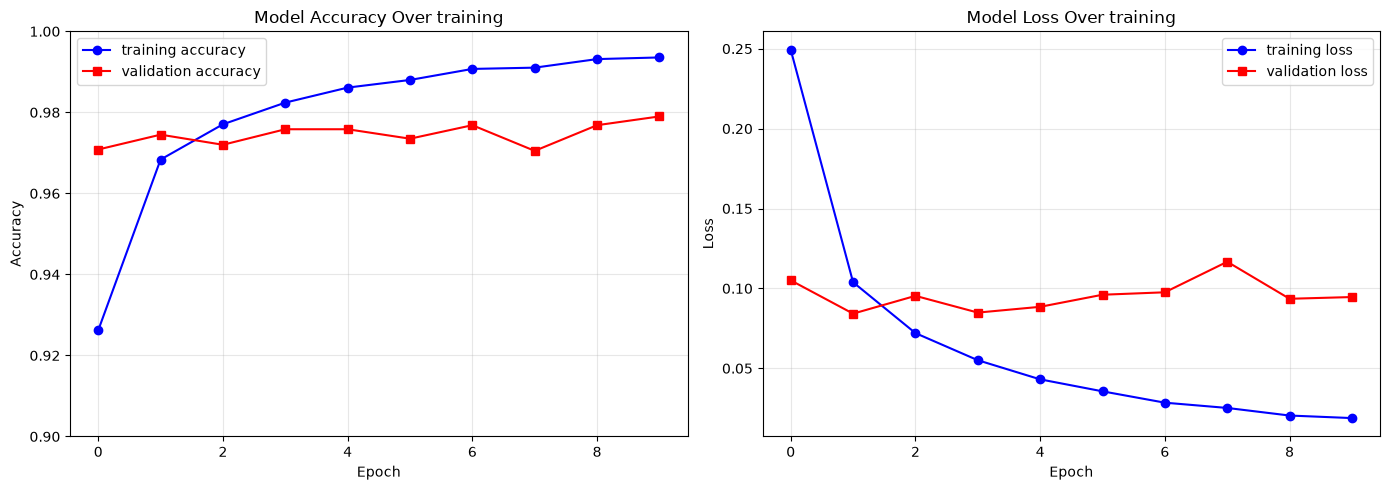

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(history.history['accuracy'], 'b-o', label='training accuracy')
ax1.plot(history.history['val_accuracy'], 'r-s', label='validation accuracy')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over training')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.9, 1.0)


ax2 = axes[1]
ax2.plot(history.history['loss'],'b-o', label='training loss')
ax2.plot(history.history['val_loss'], 'r-s', label='validation loss')

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

ax2.set_title('Model Loss Over training')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Evaluate the Model’s Performance

- Compute accuracy on the test dataset
- Display a confusion matrix for misclassified digits
- Identify which digits the model struggles with the most

In [45]:
test_loss, test_accuracy = model.evaluate(
    X_test_normal,
    y_test_encoded,
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9755 - loss: 0.1023


In [47]:
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(X_test_normal)

print(f'Prediction shape: {predictions.shape}')
print(f'Sample prediction: {predictions[0]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step
Prediction shape: (10000, 10)
Sample prediction: [1.7846784e-16 5.8504666e-11 9.8234552e-11 1.0403827e-08 8.3142248e-18
 4.7591112e-14 1.4962613e-22 9.9999994e-01 1.9971162e-14 2.3314904e-08]


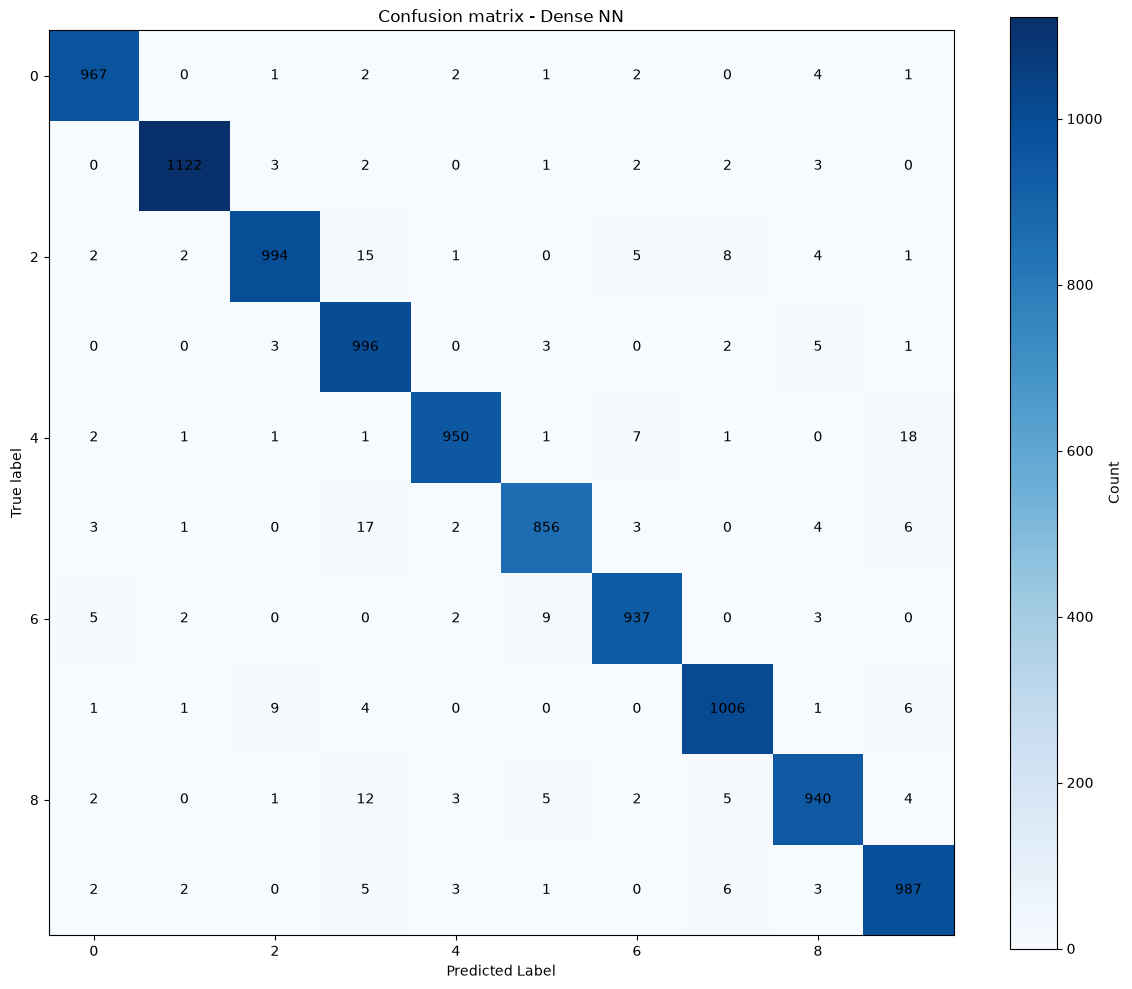

In [ ]:
y_pred = np.argmax(predictions, axis=1) 
y_true = np.argmax(y_test_encoded, axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues')
plt.colorbar(label='Count')

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j] , ha='center', va='center')

plt.xlabel('Predicted Label')
plt.ylabel('True label')
plt.title('Confusion matrix - Dense NN')
plt.tight_layout()
plt.show()


In [57]:
misclassified = cm.sum(axis=1) - np.diag(cm)   # incorrect count per true digit
error_rate = misclassified / cm.sum(axis=1)     # as a percentage of that digit's total samples
for digit in range(10):
    print(f"Digit {digit}: {misclassified[digit]} errors out of {cm.sum(axis=1)[digit]} "
          f"({error_rate[digit]*100:.2f}%)")
    
worst = np.argsort(error_rate)[::-1]
print("Digits ranked by error rate (worst first):", worst)


Digit 0: 13 errors out of 980 (1.33%)
Digit 1: 13 errors out of 1135 (1.15%)
Digit 2: 38 errors out of 1032 (3.68%)
Digit 3: 14 errors out of 1010 (1.39%)
Digit 4: 32 errors out of 982 (3.26%)
Digit 5: 36 errors out of 892 (4.04%)
Digit 6: 21 errors out of 958 (2.19%)
Digit 7: 22 errors out of 1028 (2.14%)
Digit 8: 34 errors out of 974 (3.49%)
Digit 9: 22 errors out of 1009 (2.18%)
Digits ranked by error rate (worst first): [5 2 8 4 6 9 7 3 0 1]
